# Notebook 12 – Business Insights
Dataset: `telecom_customer_churn.csv`


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
df = pd.read_csv("telecom_customer_churn.csv")
df.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure_months,phone_service,internet_service,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,CUST-10681,Male,0,Yes,No,24.0,Yes,Fiber optic,Month-to-month,Yes,Credit card,80.04,1900.19,No
1,CUST-10024,Female,0,Yes,No,35.0,Yes,Fiber optic,Month-to-month,Yes,Mailed check,42.99,1539.83,No
2,CUST-10621,Male,0,Yes,No,68.0,Yes,DSL,Month-to-month,Yes,Electronic check,79.31,5401.35,Yes
3,CUST-10099,Male,0,Yes,Yes,18.0,Yes,Fiber optic,Month-to-month,Yes,Electronic check,113.02,2022.80,No
4,CUST-10284,Male,1,Yes,Yes,34.0,Yes,No,Month-to-month,No,Electronic check,28.78,966.99,Yes


## 1. Pattern — Contract Length Is the Dominant Churn Driver

In [2]:
churn_by_contract = df.groupby("contract")["churn"].apply(lambda x: (x == "Yes").mean() * 100).round(2)
size_by_contract = df.groupby("contract").size()
pd.DataFrame({"churn_rate_pct": churn_by_contract, "customers": size_by_contract})

,churn_rate_pct,customers
contract,,
Month-to-month,45.26,559
One year,14.06,249
Two year,14.49,207


**Observation:** Month-to-month customers churn at 45.3%, more than three times the rate of one-year (14.1%) and two-year (14.5%) contract holders, even though month-to-month is also the largest segment at 559 of 1,015 customers.

**Business problem:** Over half of the customer base is on a contract type that is inherently high-risk, meaning the company is structurally exposed to churn rather than losing customers for isolated reasons.

**Opportunity:** Migrating even a fraction of month-to-month customers to one-year contracts could cut their churn probability by roughly two-thirds, based on the one-year segment's observed rate. This makes contract-length incentives (discounts, loyalty pricing) one of the highest-leverage retention levers available in this dataset.

## 2. Interesting Segment — Month-to-Month Fiber Optic Customers

In [3]:
segment = df[(df["contract"] == "Month-to-month") & (df["internet_service"] == "Fiber optic")]
overall_rate = (df["churn"] == "Yes").mean() * 100
segment_rate = (segment["churn"] == "Yes").mean() * 100
print("Segment size:", len(segment))
print("Segment churn rate (%):", round(segment_rate, 2))
print("Overall churn rate (%):", round(overall_rate, 2))

Segment size: 237
Segment churn rate (%): 45.15
Overall churn rate (%): 31.33


**Observation:** Customers who combine a month-to-month contract with fiber optic internet churn at 45.2%, compared to an overall base rate of 31.3%. This 237-customer segment stacks two individually risky attributes into one group.

**Business problem:** This is not a small edge case — it represents roughly 23% of the entire customer base, meaning nearly a quarter of all customers sit in the highest-risk configuration the company offers.

**Opportunity:** This segment should be the first target for a proactive retention campaign (contract upgrade offers, service credits, loyalty perks), since it combines high risk with meaningful scale.

## 3. Trend — Elevated Churn in the Early Tenure Window

In [4]:
early = df[df["tenure_months"] <= 6]
late = df[df["tenure_months"] > 48]
print("Tenure <= 6 months: n =", len(early), ", churn rate (%) =", round((early["churn"] == "Yes").mean() * 100, 2))
print("Tenure > 48 months: n =", len(late), ", churn rate (%) =", round((late["churn"] == "Yes").mean() * 100, 2))

Tenure <= 6 months: n = 119 , churn rate (%) = 35.29
Tenure > 48 months: n = 311 , churn rate (%) = 28.94


**Observation:** Customers in their first 6 months churn at 35.3%, compared to 28.9% for customers who have stayed more than 4 years — a meaningful gap even though it is not the largest effect in the dataset.

**Business problem:** New customers are the most fragile segment, and a poor first-six-month experience compounds the company's already high churn exposure from month-to-month contracts.

**Opportunity:** A structured onboarding program (check-in calls, first-bill support, early loyalty incentives) targeted specifically at the 0–6 month window could reduce early attrition before it compounds with contract-driven churn.

## 4. Business Problem — Revenue Currently at Risk

In [5]:
churned = df[df["churn"] == "Yes"]
monthly_at_risk = churned["monthly_charges"].sum()
total_monthly = df["monthly_charges"].sum()
pct_at_risk = monthly_at_risk / total_monthly * 100
print("Monthly recurring revenue from churned customers:", round(monthly_at_risk, 2))
print("Total monthly recurring revenue (all customers):", round(total_monthly, 2))
print("Percent of revenue at risk (%):", round(pct_at_risk, 2))

Monthly recurring revenue from churned customers: 22110.32
Total monthly recurring revenue (all customers): 70333.45
Percent of revenue at risk (%): 31.44


**Observation:** Customers who have already churned represented roughly $22,110 of monthly recurring revenue, which is 31.4% of the company's total monthly charges across the dataset.

**Business problem:** Churn is not a marginal issue here — nearly a third of billed monthly revenue is tied to customers who ultimately left, indicating the company's retention problem has a direct and sizeable revenue impact rather than being a minor operational concern.

## 5. Relationship — Family Status Is a Modest Protective Factor

In [6]:
partner_map = {"yes": "Yes", "y": "Yes", "no": "No", "n": "No"}
df["partner_clean"] = df["partner"].str.strip().str.lower().map(partner_map)

family = df[(df["partner_clean"] == "Yes") & (df["dependents"] == "Yes")]
single = df[(df["partner_clean"] == "No") & (df["dependents"] == "No")]
print("Customers with partner and dependents: n =", len(family), ", churn rate (%) =", round((family["churn"] == "Yes").mean() * 100, 2))
print("Customers with no partner and no dependents: n =", len(single), ", churn rate (%) =", round((single["churn"] == "Yes").mean() * 100, 2))

Customers with partner and dependents: n = 163 , churn rate (%) = 26.38
Customers with no partner and no dependents: n = 357 , churn rate (%) = 35.01


**Observation:** Customers with both a partner and dependents churn at 26.4%, compared to 35.0% for customers with neither — an 8.6 percentage point gap.

**Insight:** Household/family customers appear more stable, likely because switching providers is more disruptive for a shared household plan. This makes family or multi-line bundles a reasonable retention-oriented product to promote toward single, unattached customers.

## 6. Non-Drivers — Where the Data Does Not Support a Story

In [7]:
gender_map = {"female": "Female", "f": "Female", "male": "Male", "m": "Male"}
df["gender_clean"] = df["gender"].str.strip().str.lower().map(gender_map)

checks = {
    "gender_clean": df.groupby("gender_clean")["churn"].apply(lambda x: (x == "Yes").mean() * 100).round(2),
    "senior_citizen": df.groupby("senior_citizen")["churn"].apply(lambda x: (x == "Yes").mean() * 100).round(2),
    "payment_method": df.groupby("payment_method")["churn"].apply(lambda x: (x == "Yes").mean() * 100).round(2),
    "internet_service": df.groupby("internet_service")["churn"].apply(lambda x: (x == "Yes").mean() * 100).round(2),
}
for name, result in checks.items():
    print(name)
    print(result)
    print()

gender_clean
gender_clean
Female    31.13
Male      31.54
Name: churn, dtype: float64

senior_citizen
senior_citizen
0    31.06
1    32.60
Name: churn, dtype: float64

payment_method
payment_method
Bank transfer       33.58
Credit card         30.17
Electronic check    30.21
Mailed check        29.80
Name: churn, dtype: float64

internet_service
internet_service
DSL            31.36
Fiber optic    32.02
No             29.71
Name: churn, dtype: float64



**Observation:** Gender (31.1% vs 31.5%), senior citizen status (31.1% vs 32.6%), payment method (29.8%–33.6%), and internet service type (29.7%–32.0%) all show churn rates clustered tightly around the 31.3% base rate, with no gap large enough to suggest a real effect.

**Insight:** It is just as valuable to rule these out as it is to find real drivers. Any retention strategy should be built around contract type, tenure, and household composition rather than demographic or service-type segmentation, which the data does not support as meaningful churn predictors.

## 7. Anomaly — Inconsistent Category Labels Create a Reporting Trap

In [8]:
print(df["gender"].value_counts())
print()
print(df["partner"].value_counts())
print()
raw_gender_churn = df.groupby("gender")["churn"].apply(lambda x: (x == "Yes").mean() * 100).round(2)
print(raw_gender_churn)

gender
Female    498
Male      490
female      9
F           7
M           7
male        4
Name: count, dtype: int64

partner
No     501
Yes    492
yes      7
Y        7
N        5
no       3
Name: count, dtype: int64

gender
F         42.86
Female    30.92
M         57.14
Male      31.02
female    33.33
male      50.00
Name: churn, dtype: float64


**Observation:** The `gender` column contains six inconsistent labels (`Female`, `Male`, `female`, `male`, `F`, `M`) instead of two, and `partner` similarly mixes `Yes/Y/yes` and `No/N/no`. Taken at face value, the raw `gender` column shows `M` churning at 57.1% and `F` at 42.9% — dramatically different from the cleaned result of roughly 31% for both.

**Business problem:** These are not real churn differences; they are artifacts of tiny, inconsistently labeled subgroups (7 records each). If this column were analyzed without cleaning, it could lead to a false conclusion that gender drives churn, misdirecting a retention strategy toward a demographic factor that has no real effect.

**Action required:** Standardize all categorical text fields (case and label variants) before any further modeling or reporting to avoid drawing conclusions from data entry noise rather than genuine customer behavior.

## 8. Anomaly — Invalid Negative Charges

In [9]:
invalid_charges = df[df["monthly_charges"] < 0]
invalid_charges[["customer_id", "monthly_charges", "total_charges", "churn"]]

,customer_id,monthly_charges,total_charges,churn
443,CUST-10221,-97.93,2133.88,No
782,CUST-10576,-20.30,55.79,No
917,CUST-10130,-84.27,NaN,No


**Observation:** Three customers have negative `monthly_charges` values (as low as -$97.93), which is not a physically valid billing amount.

**Business problem:** This points to either a billing system error, a refund/credit that was recorded incorrectly as a charge, or a data pipeline defect. Left uncorrected, these records would distort average revenue calculations and any model trained on `monthly_charges`.

**Action required:** These records should be investigated with the billing team and corrected or excluded before they are used in revenue reporting or predictive modeling.

## 9. Supporting Visualization — Churn Rate Across Combined Contract and Internet Segments

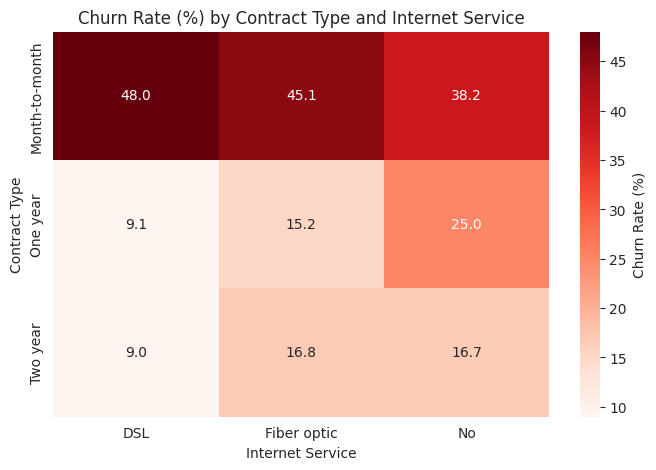

In [10]:
segment_table = df.groupby(["contract", "internet_service"])["churn"].apply(lambda x: (x == "Yes").mean() * 100).unstack().round(1)

plt.figure(figsize=(8, 5))
sns.heatmap(segment_table, annot=True, fmt=".1f", cmap="Reds", cbar_kws={"label": "Churn Rate (%)"})
plt.title("Churn Rate (%) by Contract Type and Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Contract Type")
plt.show()

**Observation:** Risk is not evenly spread across the customer base; it concentrates specifically in the month-to-month row, and is highest where month-to-month overlaps with fiber optic, while every cell in the one-year and two-year rows stays below 20%.

**Insight:** This confirms that contract type, not internet service type on its own, is the primary axis of risk — internet type only matters as a secondary amplifier within the month-to-month group.